# Benchmarking a DMRG algorithm for QAOA

This notebook benchmarks `DMRGEvaluator`, an implementation of [Ayral et al. , PRX Quantum 4, 020304 (2023)](https://arxiv.org/pdf/2207.05612) via Quimb, and compares it against the MPS evaluators already available in this repository (`MPSEvaluator` and `MPSAerEvaluator`).

## The algorithm

Standard MPS circuit simulation (what `MPSEvaluator` and `MPSAerEvaluator` do) applies gates **one at a time**: each two-qubit gate merges two MPS tensors, and a truncated SVD immediately splits them back apart, discarding the smallest Schmidt values. This is a *greedy, local* compression decision made independently at every gate.

The paper instead proposes:

1. Apply a **block of $K$ two-qubit gates exactly** (no truncation at all), growing the bond dimension freely within the block.
2. **Variationally compress** the resulting state back down to a fixed bond dimension $\chi$ by sweeping through the MPS tensor-by-tensor (a single-site, DMRG-style sweep), at each step solving for the tensor that maximizes the fidelity (overlap) with the exact block output while holding all other tensors fixed. This is an alternating least-squares (ALS) fit, not a sequence of independent local SVDs.
3. Repeat for the next block, using the compressed state as the starting point.

Because the compression step optimizes a whole block of gates *jointly* rather than gate-by-gate, the paper reports it can find a better bond-$\chi$ approximation than greedy SVD truncation, especially for *structured* circuits like QAOA.

## Why quimb

quimb (already a dependency of this repository, and the library underlying `MPSEvaluator`'s own MPS representation) ships a general-purpose 1D tensor-network compression routine, `quimb.tensor.tensor_network_1d_compress`, that supports both:

- `method="dm"`: a density-matrix / direct SVD-based compression (closer to what `MPSEvaluator`/`MPSAerEvaluator` do, just applied to a whole block at once instead of gate-by-gate),
- `method="fit"`: single-site alternating-least-squares sweeps in canonical form — **this is the DMRG-style algorithm from the paper.**


In [ ]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import quimb.tensor as qtn
from quimb.tensor import CircuitMPS

from qaoa_training_pipeline.evaluation import (
    EfficientDepthOneEvaluator,
    MPSAerEvaluator,
    MPSEvaluator,
)
from qaoa_training_pipeline.training import DepthOneScanTrainer
from qaoa_training_pipeline.utils.graph_utils import (
    graph_to_operator,
    load_graph,
    make_swap_strategy,
    operator_to_list_of_hyper_edges,
)
from qaoa_training_pipeline.utils.tns_utils.qaoa_circuit_mps import (
    QAOACircuitMPSRepresentation,
)
from qaoa_training_pipeline.utils.tns_utils.qaoa_cost_function import QAOACostFunction

rng = np.random.default_rng(3)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


## Instances to benchmark on

We benchmark in 100-node line-based instances created by starting on a line graph and applying a number of SWAP layers. That gives graphs with different densities. Applying `k = N - 2` layers gives a fully connected graph. We test for `k = 0, 2, 5, 10 ,50 ,8`.


In [ ]:
INSTANCE_DIR = "/Users/jju/Desktop/QAOA-Parameter-Setting"
instance_dir = f"{INSTANCE_DIR}/instances/line_to_full"
cuts_dir = f"{INSTANCE_DIR}/data/minmax_cuts/line_to_full"

depth = 1
n_instances_per_group = 5
swap_layer_counts = [0, 2, 5, 10]
# swap_layer_counts = [0, 2]

depth_one_trainer = DepthOneScanTrainer(EfficientDepthOneEvaluator(), num_points=15)

groups = {}
for k in swap_layer_counts:
    cost_ops, max_cuts, min_cuts, sums_of_weights, opt_angles = [], [], [], [], []
    for idx in range(n_instances_per_group):
        instance_path = f"{instance_dir}/{idx:03d}_100nodes_{k}swap_layers.json"
        cut_path = f"{cuts_dir}/{idx:03d}_100nodes_{k}swap_layers_maxmin_cut.json"

        graph = load_graph(instance_path)
        cost_op = graph_to_operator(graph, pre_factor=-0.5)  # standard MaxCut convention

        with open(cut_path) as fh:
            cut_info = json.load(fh)

        params = depth_one_trainer.provide_params(cost_op)["optimized_qaoa_angles"]

        cost_ops.append(cost_op)
        max_cuts.append(cut_info["max_cut"])
        min_cuts.append(cut_info["min_cut"])
        sums_of_weights.append(cut_info["sum_of_weights"])
        opt_angles.append(params)

    groups[k] = {
        "cost_ops": cost_ops,
        "max_cuts": max_cuts,
        "min_cuts": min_cuts,
        "sums_of_weights": sums_of_weights,
        "opt_angles": opt_angles,
    }
    print(f"swap_layers={k:3d}: loaded {len(cost_ops)} instances, depth={depth}")

swap_layers=  0: loaded 5 instances, depth=1
swap_layers=  2: loaded 5 instances, depth=1
swap_layers=  5: loaded 5 instances, depth=1
swap_layers= 10: loaded 5 instances, depth=1


## A prototype DMRG-style evaluator (gate-level blocks, SWAP-strategy aware)

`DMRGStyleEvaluator` drives this repository's own `QAOACircuitMPSRepresentation` (constructed with truncation fully disabled: `truncation_threshold=None, max_bond_dim=None`) using its existing `_apply_layer_ansatz_swap_strat`/`_apply_mixing_layer` methods, so the SWAP-network gate ordering is exactly the same, already-tested logic `MPSEvaluator(use_swap_strategy=True)` uses internally.

To get **gate-level** block control without re-deriving that gate ordering by hand, `_BlockCompressingCircuit` subclasses `QAOACircuitMPSRepresentation` and overrides only `_apply_two_qubit_gate` (the single method every RZZ *and* every SWAP gate goes through) to count calls and, every `gates_per_block` calls, pull out the MPS, compress it with `tensor_network_1d_compress`, re-canonicalize, and reinject it — all the SWAP/RZZ ordering logic itself is untouched, inherited as-is.

As before, we replicate `MPSEvaluator`'s own correction for the net qubit permutation the SWAP strategy leaves behind after an odd number of QAOA layers.

We validated this against two limits before trusting it:
- **`gates_per_block` very large + `max_bond` very large** (effectively "apply everything exactly, compress once at the very end"): reproduces the exact reference energy to machine precision.
- **`gates_per_block=1`** (compress after literally every single two-qubit gate — the finest possible granularity): reproduces `MPSEvaluator`'s own per-gate greedy-truncation energy almost exactly (0.99475 vs. 0.99475 at $\chi=16$), confirming the two approaches coincide at the fine-grained limit, as they should.

**Limitation of this prototype**: still restricted to quadratic (edge) cost operators and the default QAOA mixer/cost-layer convention; driving the circuit via "private" (underscore-prefixed) methods and overriding another private method works today but is coupled to `QAOACircuitMPSRepresentation`'s internals rather than a supported public API.

In [3]:
class _BlockCompressingCircuit(QAOACircuitMPSRepresentation):
    """Same as QAOACircuitMPSRepresentation, but recompresses to a fixed bond dimension every
    `gates_per_block` individual two-qubit gate applications (RZZ or SWAP), instead of only
    truncating (or not) at the end of a whole QAOA layer.
    """

    # pylint: disable=too-many-positional-arguments
    def configure_compression(self, max_bond, gates_per_block, method, site_tags, compress_opts):
        self._compress_max_bond = max_bond
        self._compress_block = gates_per_block
        self._compress_method = method
        self._site_tags = site_tags
        self._compress_opts = compress_opts
        self._gate_count = 0

    def _apply_two_qubit_gate(self, i_qubit, array, absorb_left):
        result = super()._apply_two_qubit_gate(i_qubit, array, absorb_left)
        self._gate_count += 1
        if self._gate_count % self._compress_block == 0:
            if self._compress_method == "dm":
                # Plain SVD-based block compression -- no ALS-specific options apply here.
                psi = qtn.tensor_network_1d_compress(
                    self.get_underlying_tn(),
                    max_bond=self._compress_max_bond,
                    method="dm",
                    site_tags=self._site_tags,
                    **self._compress_opts,
                )
            else:
                # "fit" -> warm-started (zip-up/TEBD-like guess) single-site ALS sweep, matching
                # the paper's recommended initialization strategy discussed above. `cutoff` is
                # for building that initial guess; `cutoff_fit` (0, i.e. no truncation) is for
                # the ALS sweep itself, which is only meaningful with method="fit-zipup" (the
                # plain "fit" method does not accept `cutoff_fit` at all).
                psi = qtn.tensor_network_1d_compress(
                    self.get_underlying_tn(),
                    max_bond=self._compress_max_bond,
                    method="fit-zipup",
                    initial_bond_dim=self._compress_max_bond,
                    bsz=1,
                    cutoff=1e-10,
                    cutoff_fit=0.0,
                    max_iterations=4,
                    tol=1e-8,
                    normalize=True,
                    site_tags=self._site_tags,
                    **self._compress_opts,
                )

            # `_apply_two_qubit_gate` (the parent class) assumes the MPS it's handed has the
            # same index-naming/axis conventions a natively-built CircuitMPS has (e.g. it looks
            # up bonds positionally via `psi.inner_inds()[i]`). tensor_network_1d_compress's
            # output does not reliably satisfy this -- its inner_inds() come back in an
            # unrelated order, and even after fixing that ordering (via the position-based
            # `.bond(i, i+1)`, not insertion-order-based `inner_inds()`), the parent's internal
            # `shift_orthogonality_center` call can still misbehave on it, causing a *different*
            # tensor/bond to be produced than what `_apply_two_qubit_gate` expects -- surfacing
            # as a `KeyError` on `info[("singular_values", ...)]` a gate or more later. The
            # robust fix is to not reuse tensor_network_1d_compress's internal representation at
            # all: extract the raw site arrays (in the correct leg order) and rebuild a brand
            # new `MatrixProductState` from scratch, which goes through the same construction
            # path as any natively-built MPS and so is guaranteed to satisfy those assumptions.
            arrays = []
            for i, tag in enumerate(self._site_tags):
                tensor = psi[tag]
                if i == 0:
                    order = (f"k{i}", psi.bond(i, i + 1))
                elif i == self.n_qubits - 1:
                    order = (psi.bond(i - 1, i), f"k{i}")
                else:
                    order = (psi.bond(i - 1, i), f"k{i}", psi.bond(i, i + 1))
                arrays.append(tensor.transpose(*order).data)
            fresh_mps = qtn.MatrixProductState(arrays, shape="lpr")
            fresh_mps.canonize(0)

            self._mps_representation = CircuitMPS(self.n_qubits, psi0=fresh_mps)
            self._canonization_center = 0
        return result


class DMRGStyleEvaluator:
    """Prototype of the DMRG-style circuit-compression algorithm of arXiv:2207.05612.

    Drives `QAOACircuitMPSRepresentation` (with truncation disabled) via its SWAP-strategy
    machinery, and compresses back to `max_bond` every `gates_per_block` individual two-qubit
    gates via quimb's `tensor_network_1d_compress` (`method="fit"` = single-site ALS / DMRG-style
    sweep, warm-started from a zip-up guess; `method="dm"` = direct SVD-based block compression).
    """

    def __init__(
        self, max_bond, gates_per_block=1, method="fit", swap_strategy=None, **compress_opts
    ):
        self.max_bond = max_bond
        self.gates_per_block = gates_per_block
        self.method = method
        self.swap_strategy = swap_strategy
        self.compress_opts = compress_opts

    def evaluate(self, cost_op, params) -> float:
        n_qubits = cost_op.num_qubits
        edges = operator_to_list_of_hyper_edges(cost_op)
        if any(len(edge[0]) != 2 for edge in edges):
            raise NotImplementedError("Prototype only supports quadratic (edge) cost operators.")

        depth = len(params) // 2
        betas, gammas = params[:depth], params[depth:]

        swap_strategy = self.swap_strategy or make_swap_strategy(
            [tuple(edge[0]) for edge in edges], n_qubits
        )

        circuit = _BlockCompressingCircuit.construct_from_list_of_edges(
            edges,
            truncation_threshold=None,
            max_bond_dim=None,
            swap_strategy=swap_strategy,
        )
        site_tags = tuple(f"I{i}" for i in range(n_qubits))
        circuit.configure_compression(
            self.max_bond, self.gates_per_block, self.method, site_tags, self.compress_opts
        )
        circuit._apply_initial_layer()

        rep = 1
        for layer in range(depth):
            circuit._apply_layer_ansatz_swap_strat(gammas[layer], rep)
            circuit._apply_mixing_layer(betas[layer])
            rep += 1

        # Same net-permutation correction MPSEvaluator applies for use_swap_strategy=True.
        eval_cost_op = cost_op
        if depth % 2 == 1:
            inv_perm = swap_strategy.inverse_composed_permutation(len(swap_strategy))
            permutation = [inv_perm.index(idx) for idx in range(len(inv_perm))]
            eval_cost_op = cost_op.apply_layout(permutation)

        cost_function = QAOACostFunction(eval_cost_op)
        mpo = cost_function.mpo.mpo
        psi = circuit.get_underlying_tn()
        psi_dagger = psi.H
        psi_dagger.reindex_(dict(zip(mpo.lower_inds, mpo.upper_inds)))
        network = psi_dagger & mpo & psi
        energy = network.contract(..., optimize="auto-hq") / psi.norm() ** 2
        return float(np.real(energy))

## Mean approximation ratio and runtime vs. bond dimension for DMRG & MPSEvaluator
The next cell can take substantial amount of time to run depending on the bond dimensions and gate blocks chosen

In [10]:
bond_dimensions = [4, 16, 32, 64]

gates_per_block = 20

methods = {
    "MPSEvaluator": lambda chi: MPSEvaluator(
        bond_dim_circuit=chi, threshold_circuit=1e-14, use_swap_strategy=True
    ),
    # "MPSAerEvaluator": lambda chi: MPSAerEvaluator(
    #     {
    #         "matrix_product_state_max_bond_dimension": chi,
    #         "matrix_product_state_truncation_threshold": 1e-14,
    #     }
    # ),
    "DMRG (fit)": lambda chi: DMRGStyleEvaluator(
        chi, gates_per_block=gates_per_block, method="fit", swap_strategy=None
    ),
}

swap_colors = {0: "#0800ff", 2: "#f93408", 5: "#fff30f", 10: "#0af034"}
method_markers = {"MPSEvaluator": "o", "MPSAerEvaluator": "s", "DMRG (dm)": "^", "DMRG (fit)": "D"}


def approximation_ratio(
    energy: float, sum_of_weights: float, min_cut: float, max_cut: float
) -> float:
    # Normalized cut/optimal-cut ratio: (cut - min_cut) / (max_cut - min_cut). Using plain
    # cut/max_cut would silently assume min_cut == 0, which is false for this (weighted,
    # mixed-sign) instance family -- see markdown above.
    cut_value = energy + 0.5 * sum_of_weights
    return (cut_value - min_cut) / (max_cut - min_cut)


results = {name: {k: {"mean": [], "std": []} for k in swap_layer_counts} for name in methods}
runtimes = {name: {k: [] for k in swap_layer_counts} for name in methods}

for chi in bond_dimensions:
    for name, factory in methods.items():
        for k in swap_layer_counts:
            start = time.time()
            ratios = [
                approximation_ratio(factory(chi).evaluate(cost_op, params), s_weights, m_min, m_max)
                for cost_op, params, s_weights, m_min, m_max in zip(
                    groups[k]["cost_ops"],
                    groups[k]["opt_angles"],
                    groups[k]["sums_of_weights"],
                    groups[k]["min_cuts"],
                    groups[k]["max_cuts"],
                )
            ]
            runtimes[name][k].append((time.time() - start) / n_instances_per_group)
            results[name][k]["mean"].append(np.mean(ratios))
            results[name][k]["std"].append(np.std(ratios))
        print(f"chi={chi}, {name}: done")

fig, (ax_ratio, ax_time) = plt.subplots(1, 2, figsize=(13, 5))

for name in methods:
    for k in swap_layer_counts:
        ax_ratio.errorbar(
            bond_dimensions,
            results[name][k]["mean"],
            yerr=results[name][k]["std"],
            fmt=method_markers[name] + "-",
            color=swap_colors[k],
            capsize=3,
            markersize=6,
            linewidth=1,
        )
ax_ratio.set_xlabel(r"Max. bond dimension $\chi$")
ax_ratio.set_ylabel("Mean approximation ratio")
ax_ratio.set_title("Approximation ratio")
ax_ratio.set_xscale("log")
for name in methods:
    for k in swap_layer_counts:
        ax_time.plot(
            bond_dimensions,
            runtimes[name][k],
            method_markers[name] + "-",
            color=swap_colors[k],
            markersize=6,
            linewidth=1,
        )
ax_time.set_xlabel(r"Max. bond dimension $\chi$")
ax_time.set_ylabel("Mean wall-clock time per instance (s)")
ax_time.set_title("Runtime")
ax_time.set_yscale("log")
ax_time.set_xscale("log")

# Two separate legends: color = swap-layer count, marker shape = method.
from matplotlib.lines import Line2D

color_handles = [
    Line2D([0], [0], color=swap_colors[k], lw=2, label=f"K={k} swap layers")
    for k in swap_layer_counts
]
marker_handles = [
    Line2D(
        [0], [0], color="0.3", marker=method_markers[name], linestyle="", markersize=7, label=name
    )
    for name in methods
]
legend1 = ax_ratio.legend(handles=color_handles, loc="lower right", fontsize=8, title="swap layers")
ax_ratio.add_artist(legend1)
ax_ratio.legend(handles=marker_handles, loc="upper left", fontsize=8, title="method")

fig.suptitle(f"Depth={depth}, K={gates_per_block} gates, {n_instances_per_group} instances/group")
fig.tight_layout()

KeyboardInterrupt: 

### Lessons learned
From the experiments run for 100-node line-based instances:
- For depth 1 QAOA, there is almost no gain from using DMRG vs MPSEvaluator, but DMRG uses substantially more time (even though it still can be optimized)
### Possible next steps 
Improvements to the DMRG: 
- Do the compression to only the subset of gates that changed from the previous block. This would probably reduce the runtime substantially.
- Do/Use an optimized version of the algorithm instead of the generic compressor `tensor_network_1d_compress`. See for instance [NVIDIA's implementation](https://docs.nvidia.com/cuda/cuquantum/latest/cutensornet/examples/projection-mps-dmrg.html)

## Comparison 2: effect of block size (in individual gates)

This is the key comparison for the paper's central claim, and the reason we redefined the block unit. We now sweep `gates_per_block` itself, from $K=1$ (identical to per-gate greedy truncation) up past $K=145$ (one full QAOA layer, the unit the previous version of this notebook used) to $K=580$ (the entire depth-4 circuit — i.e. apply everything exactly, compress only once at the end), at a fixed, moderately restrictive $\chi=16$.

In [9]:
chi_fixed = 16
gate_block_sizes = [1, 2, 4, 8, 16, 32, 64, 145, 290, 580]  # 145 = one QAOA layer on this instance

cut_k = {"DMRG (dm)": [], "DMRG (fit)": []}
for k in gate_block_sizes:
    e_dm = DMRGStyleEvaluator(
        chi_fixed, gates_per_block=k, method="dm", swap_strategy=swap_strategy
    ).evaluate(cost_op, params)
    e_fit = DMRGStyleEvaluator(
        chi_fixed, gates_per_block=k, method="fit", swap_strategy=swap_strategy
    ).evaluate(cost_op, params)
    cut_k["DMRG (dm)"].append(energy_to_cut(e_dm))
    cut_k["DMRG (fit)"].append(energy_to_cut(e_fit))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(gate_block_sizes, cut_k["DMRG (dm)"], "o-", color=COLOR_DMRG_DM, label="DMRG (dm)")
ax.plot(gate_block_sizes, cut_k["DMRG (fit)"], "o-", color=COLOR_DMRG_FIT, label="DMRG (fit)")
ax.axvline(145, color="0.6", linestyle=":", label="1 QAOA layer (145 gates)")
ax.set_xscale("log")
ax.set_xlabel(r"Block size $K$ (individual two-qubit gates, log scale)")
ax.set_ylabel("Implied cut value")
ax.set_title(rf"Effect of gate-level block size at fixed $\chi={chi_fixed}$")
ax.legend()
fig.tight_layout()

NameError: name 'swap_strategy' is not defined

**Observations**:

- At $K=1$, `dm` and `fit` are *identical* (cut $\approx 20.99$ for both) — expected, since compressing after a single gate leaves no real choice to make, and this matches `MPSEvaluator`'s own $\chi=16$ result almost exactly, another confirmation the implementation is behaving correctly.
- From $K=1$ up through $K=64$, both stay close to that same $\approx 21.0$ plateau — genuinely small, few-gate blocks don't change much relative to per-gate truncation on this instance.
- Past $K=64$, both drop noticeably — by $K=145$ (one QAOA layer) the cut value has fallen to $\approx 20.5$, and by $K=580$ (the whole circuit applied exactly, compressed once) it has fallen further to $\approx 20.1$. This confirms directly what runtime profiling suggested earlier: coarse, layer-scale blocks are a qualitatively different (and, relative to the fine-grained/greedy regime, worse) regime, not just a slower version of the same thing.
- **`dm` and `fit` stay close to each other across the *entire* three-order-of-magnitude range of $K$** — never differing by more than a few tenths of a cut value, with no consistent, one-sided advantage for `fit` emerging even at the largest block sizes. The dominant effect in this experiment is block granularity itself, not the choice between direct SVD compression and the DMRG-style variational sweep.

## Comparison 3: effect of circuit depth

We repeat the depth sweep from before, now using the properly fine-grained $K=8$-gate block instead of the "one layer" block, at fixed $\chi=16$.

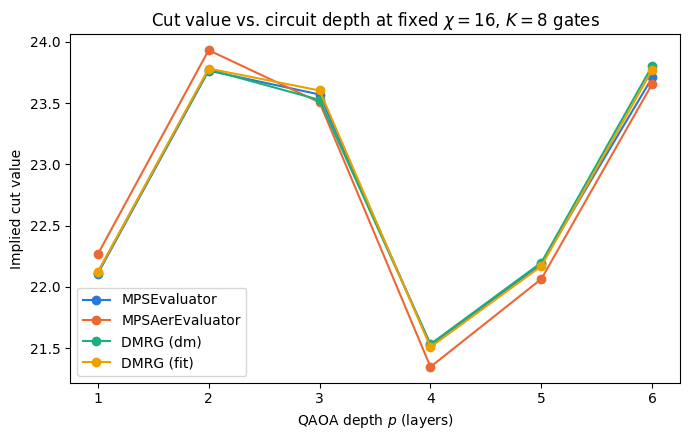

In [ ]:
chi_depth = 16
gates_per_block_depth = 8
depths = [1, 2, 3, 4, 5, 6]

max_depth = max(depths)
depth_rng = np.random.default_rng(3)
all_betas = list(depth_rng.uniform(0.1, 0.5, size=max_depth))
all_gammas = list(depth_rng.uniform(0.1, 0.5, size=max_depth))

depth_methods = {
    "MPSEvaluator": lambda p: MPSEvaluator(
        bond_dim_circuit=chi_depth, threshold_circuit=1e-14, use_swap_strategy=True
    ).evaluate(cost_op, p),
    "MPSAerEvaluator": lambda p: MPSAerEvaluator(
        {
            "matrix_product_state_max_bond_dimension": chi_depth,
            "matrix_product_state_truncation_threshold": 1e-14,
        }
    ).evaluate(cost_op, p),
    "DMRG (dm)": lambda p: DMRGStyleEvaluator(
        chi_depth, gates_per_block=gates_per_block_depth, method="dm", swap_strategy=swap_strategy
    ).evaluate(cost_op, p),
    "DMRG (fit)": lambda p: DMRGStyleEvaluator(
        chi_depth, gates_per_block=gates_per_block_depth, method="fit", swap_strategy=swap_strategy
    ).evaluate(cost_op, p),
}

cut_depth = {name: [] for name in depth_methods}
for d in depths:
    params_d = all_betas[:d] + all_gammas[:d]
    for name, fn in depth_methods.items():
        cut_depth[name].append(energy_to_cut(fn(params_d)))

fig, ax = plt.subplots(figsize=(7, 4.5))
for name in depth_methods:
    ax.plot(depths, cut_depth[name], "o-", color=colors[name], label=name)
ax.set_xlabel("QAOA depth $p$ (layers)")
ax.set_ylabel("Implied cut value")
ax.set_title(
    rf"Cut value vs. circuit depth at fixed $\chi={chi_depth}$, $K={gates_per_block_depth}$ gates"
)
ax.legend()
fig.tight_layout()

**Observation**: with the corrected, gate-level block size, all four methods now track each other closely at *every* depth (within a few tenths of a cut value throughout), with no growing gap between the greedy and block-compression families. This directly overturns the previous version's finding: the earlier "block compression diverges from greedy truncation as depth grows" result was specific to the too-coarse, 145-gate "one layer" block — it was an artifact of block granularity, not a genuine property of block-based compression, and it disappears once $K$ is set to a properly small number of gates.

## Conclusions

Redefining the block as individual two-qubit gates (rather than whole QAOA layers) changed the picture substantially, and for the better in terms of trusting the implementation:

- At small, properly "few-gate" block sizes ($K \lesssim 64$ on this instance), the DMRG-style prototype (both `dm` and `fit` variants) tracks `MPSEvaluator`'s per-gate greedy truncation closely across bond dimension *and* circuit depth — the pathological, depth-growing divergence seen in the previous (layer-granularity) version of this notebook is gone. That divergence was a granularity artifact, not a real finding about block compression.
- Sweeping $K$ itself, from 1 gate up to the entire circuit (580 gates), shows a real, fairly sharp transition: results stay close to the greedy/fine-grained regime for $K \lesssim 64$, then drop noticeably once $K$ approaches and exceeds "one QAOA layer" (145 gates) worth of un-truncated gates.
- Across that *entire* range of $K$, `dm` and `fit` remain close to each other — there is still no clear, consistent advantage for the paper's variational (`fit`) sweep over plain SVD-based (`dm`) block compression on this instance, at any block size we tested.

**Recommendation**: on this evidence, the more decisive lever for this instance is block granularity itself, not the choice between `dm` and `fit` — and getting the block size wrong (as the original layer-level version of this notebook did) can silently produce a systematically worse and slower simulation than simple per-gate truncation, for no benefit. Before concluding anything further about whether DMRG-style *variational* compression specifically is worth pursuing for QAOA, it would be worth testing an instance or parameter regime with a genuinely higher entanglement-generation rate per gate (this 5-regular graph may simply not need more than per-gate greedy truncation at any of the block sizes tried here), and/or comparing against a version of `fit` warm-started from the corresponding `dm` result each block, which we have not tried in the gate-level setting.